In [1]:
%pip install gensim>=4.1.2

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import nltk
#from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from wordcloud import WordCloud
from collections import Counter
from sklearn.metrics import silhouette_score
from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import LatentDirichletAllocation, PCA
from sklearn.feature_extraction.text import CountVectorizer
import random
np.random.seed(42)
random.seed(42)
from gensim.parsing.preprocessing import STOPWORDS
from gensim.utils import simple_preprocess
from gensim.corpora import Dictionary, MmCorpus
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary
import time

In [3]:
data_df = pd.read_csv(r'C:\Users\Shankar\Desktop\Coursework\Introduction to AI and Text Analytics\TextAnalytics-CW-Task4\analytics_pipeline\data\customer_support_tickets.csv')
data_df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


## Preprocessing

In [4]:
# for i in range(len(data_df)):
#     product_purchased = data_df.iloc[i]['Product Purchased']
#     text = data_df.iloc[i]['Ticket Description']
#     updated_text = text.replace('{product_purchased}', product_purchased)
#     data_df.at[data_df.index[i], 'Ticket Description'] = updated_text


# data_df.head()

In [5]:
duplicates = data_df['Ticket Description'].duplicated()
duplicates.sum()

np.int64(392)

In [6]:
data_df = data_df.drop_duplicates(subset=['Ticket Description'], keep='first')
data_df.reset_index(drop=True, inplace=True)

In [7]:
#data_df['text'] = data_df['Ticket Subject'].fillna('') + " " + data_df['Ticket Description'].fillna('')
data_df['text'] = data_df['Ticket Description'].fillna('')

In [8]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\{.*?\}|\[.*?\]|<.*?>|\(.*?\)', ' ', text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text) # remove URLs
    text = re.sub(r'[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+', ' ', text) # remove email addresses
    text = re.sub(r'[^\x00-\x7F]+', ' ', text) # remove non-ASCII characters
    text = re.sub(r'[^a-z\s]', '', text) 
    text = re.sub(r'\b[a-zA-Z]{1,2}\b', '', text)  # remove very short words
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data_df['clean_text'] = data_df['text'].apply(clean_text)
data_df['clean_text'].head()

0    having issue with the please assist your billi...
1    having issue with the please assist you need c...
2    facing problem with the not turning was workin...
3    having issue with the please assist you have p...
4    having issue with the please assist note the s...
Name: clean_text, dtype: str

In [35]:
# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('wordnet')

# stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# removing the words from the word cloud which i did above
#custom_words = {'please', 'help', 'issue', 'product', 'customer'}


###overfitting
# custom_words = {
#     'please', 'help', 'assist', 'support', 'thanks', 'thank','would',
#     'could', 'im', 'ive', 'issue','problem','hoping','contacted','tried',
#     'trying', 'check', 'checked', 'perform', 'performed','need', 'want',
#     'using', 'use', 'used', 'user', 'us','time','happening','everything',
#     'something', 'anything','customer', 'product', 'purchased', 'request',
#     'refund', 'payment', 'delivery', 'item','also', 'already', 'multiple',
#     'recently','didnt', 'did','get', 'getting', 'make', 'made','data','step',
#     'noticed','work','fine','available','facing','might','option','say', 'find',
#     'doe', 'like', 'seems', 'guide', 'message','sure', 'soon', 'mean', 'different',
#     'productivity', 'specific', 'troubleshooting', 'troubleshoot',
#     'possible', 'action', 'setting', 'setup', 'installation',
#     'recommendation', 'assistance','way','sometimes','act','related','havent',
#     'information', 'try','desired','new','recent','afterward','affecting','cancellation','contact', 'remains', 'occuring',
#     'account', 'device', 'hardware', 'network',
#     'software', 'compatibility', 'working', 'properly', 'configuration',
#     'none', 'update', 'updated', 'started',
#     'order', 'purchase', 'name', 'email',
#     'access', 'display', 'know', 'loss',
#     'fix', 'price', 'one', 'add', 'note', 'may', 'dont', 'store'

# }

####too harsh
# custom_words = {
#     'please', 'help', 'assist', 'support', 'thanks', 'thank','would',
#     'could', 'im', 'ive', 'issue','problem','hoping','contacted','tried',
#     'trying', 'check', 'checked', 'perform', 'performed','need', 'want',
#     'using', 'use', 'used', 'user', 'us','time','happening','everything',
#     'something', 'anything','customer', 'product', 'purchased', 'request',
#     'refund', 'payment', 'delivery', 'item','also', 'already', 'multiple',
#     'recently','didnt', 'did','get', 'getting', 'make', 'made','data','step',
#     'noticed','work','fine','available','facing','might','find','does',
#     'seems', 'guide','sure','soon','different','productivity','specific',
#     'possible','setup','installation','recommendation','assistance','way',
#     'sometimes','act','related','havent','information','try','desired','new',
#     'recent','afterward','affecting','cancellation','contact','remains','occuring',
#     'working','properly','none','order','purchase','name','email',
#     'know','price','one','add','note','may','dont','store'
# }

####not very proper clusters
# custom_words = {
#     'please', 'help', 'assist', 'support', 'thanks', 'thank','soon','mentioned',
#     'im', 'ive', 'us','would', 'could', 'need', 'want', 'trying',
#     'tried','check', 'checked', 'make', 'made', 'get', 'getting','also',
#     'use', 'using', 'used','thing', 'something', 'anything', 'everything',
#     'way', 'time','issue', 'problem', 'request',
#     'fine', 'available', 'recent', 'recently','facing', 'doe',
#     'noticed', 'happening', 'started', 'happen','different', 'steps', 'did',
#     'regards','already', 'multiple','last','times','followed', 'reviewed',
#     'specific', 'possible', 'related', 'find', 'try', 'trying', 'say', 'mean',
#     'name', 'email', 'one', 'add','note', 'may', 'dont', 'know','sure',
#     'changes', 'performed', 'properly', 'like', 'similar','reported','doesnt',
#     'sometimes', 'acts', 'ensure', 'desired', 'action', 'remains', 'seems',
#     'might', 'guide', 'much', 'others',
#     'heavily', 'daily', 'task',
#     'affecting', 'assistance',
#     'hoping','persists','didnt',
#     'option', 'perform', 'recommendation', 'official',
#     'provide', 'making',
#     'user', 'customer',
#     'far', 'luck','contact', 'contacted', 'occurring', 'having','various', 'performing', 'id', 'peculiar', 'popping', 'many', 'havent',
#     'order', 'function', 'came', 'change', 'haven', 'let', 'able', 'afterward', 'var', 'step'
# }

custom_words = {
    'please', 'help', 'assist', 'support', 'thanks', 'thank','soon','mentioned',
    'im', 'ive', 'us','would', 'could', 'need', 'want', 'trying',
    'tried','check', 'checked', 'make', 'made', 'get', 'getting','also',
    'use', 'using', 'used','thing', 'something', 'anything', 'everything',
    'way', 'time','issue', 'problem', 'request',
    'work', 'working', 'fine', 'available', 'recent', 'recently','facing', 'doe',
    'noticed', 'happening', 'started', 'happen','different', 'steps', 'did',
    'regards','already', 'multiple','last','times','followed', 'reviewed',
    'specific', 'possible', 'related','new', 'old','find', 'try', 'trying', 'say', 'mean',
    'name', 'email', 'price', 'one', 'add','note', 'may', 'dont', 'know','sure',
    'changes', 'performed', 'properly','original','like', 'similar','reported','doesnt',
    'sometimes', 'acts', 'works', 'ensure', 'desired', 'action', 'remains', 'life', 'seems',
    'might', 'guide', 'much', 'others',
    'heavily', 'daily', 'task',
    'affecting', 'assistance',
    'hoping','persists','didnt',
    'option', 'perform', 'recommendation', 'information', 'official',
    'solution', 'provide', 'making',
    'user', 'customer',
    'item', 'device',
    'far', 'luck','contact', 'contacted', 'occurring',
    'resolve', 'function', 'came', 'having', 'unresolved', 'change', 'haven', 'let', 'unable', 'able', 'afterward', 'var', 'step', 'order'
}

custom_words2 = {'please', 'assist', 'issue', 'persists', 'product' 'using', 'help', 'resolve', 'function', 'var', 'let', 'having', 'problem'}


# {
#     'solution', 'provide', 'making',
#     'user', 'customer',
#     'item', 'device',
#     'far', 'luck','contact', 'contacted', 'occurring'
# }
# {
#     'customer', 'product', 'purchased', 'order', 'purchase',
#     'refund', 'payment', 'delivery', 'item'
# }
# 'customer', 'product',
# 'refund', 'payment', 'delivery',
# 'order', 'purchase', 'item'
# 'refund', 'payment', 'delivery', 'order', 'purchase', 'product'
# 'issue', 'problem', 'request'
#    'hoping', 'contacted','perform', 'performed','step','unresolved', 'persists',
#   'information'

#'hardware', 'software', 'account'
# remmvoing the workds 'software', 'device', 'issue' as they are very common and not useful for clustering

final_stopwords = STOPWORDS.union(custom_words)
custom_words_lemma = set([lemmatizer.lemmatize(w.lower()) for w in final_stopwords])

def preprocess(text):
    text = str(text).lower()
    tokens = simple_preprocess(text, deacc=True)

    
    processed_tokens = []
    
    for word in tokens:
        lemma = lemmatizer.lemmatize(word)
        if (lemma not in custom_words_lemma and 
            len(lemma) > 2 and 
            lemma.isalnum()):
            processed_tokens.append(lemma)
    
    return " ".join(processed_tokens)
data_df['processed_text'] = data_df['clean_text'].apply(preprocess)

In [10]:
print(custom_words2 - custom_words)

{'productusing'}


In [11]:
print(len(data_df['processed_text']))

8077


In [12]:
data_df[['text', 'processed_text']].head(5)

,text,processed_text
0,I'm having an issue with the {product_purchase...,billing zip code appreciate requested website ...
1,I'm having an issue with the {product_purchase...,existing product intermittent unexpectedly
2,I'm facing a problem with my {product_purchase...,turning yesterday respond charger charging
3,I'm having an issue with the {product_purchase...,youre interested love feedback
4,I'm having an issue with the {product_purchase...,seller responsible damage arising delivery bat...


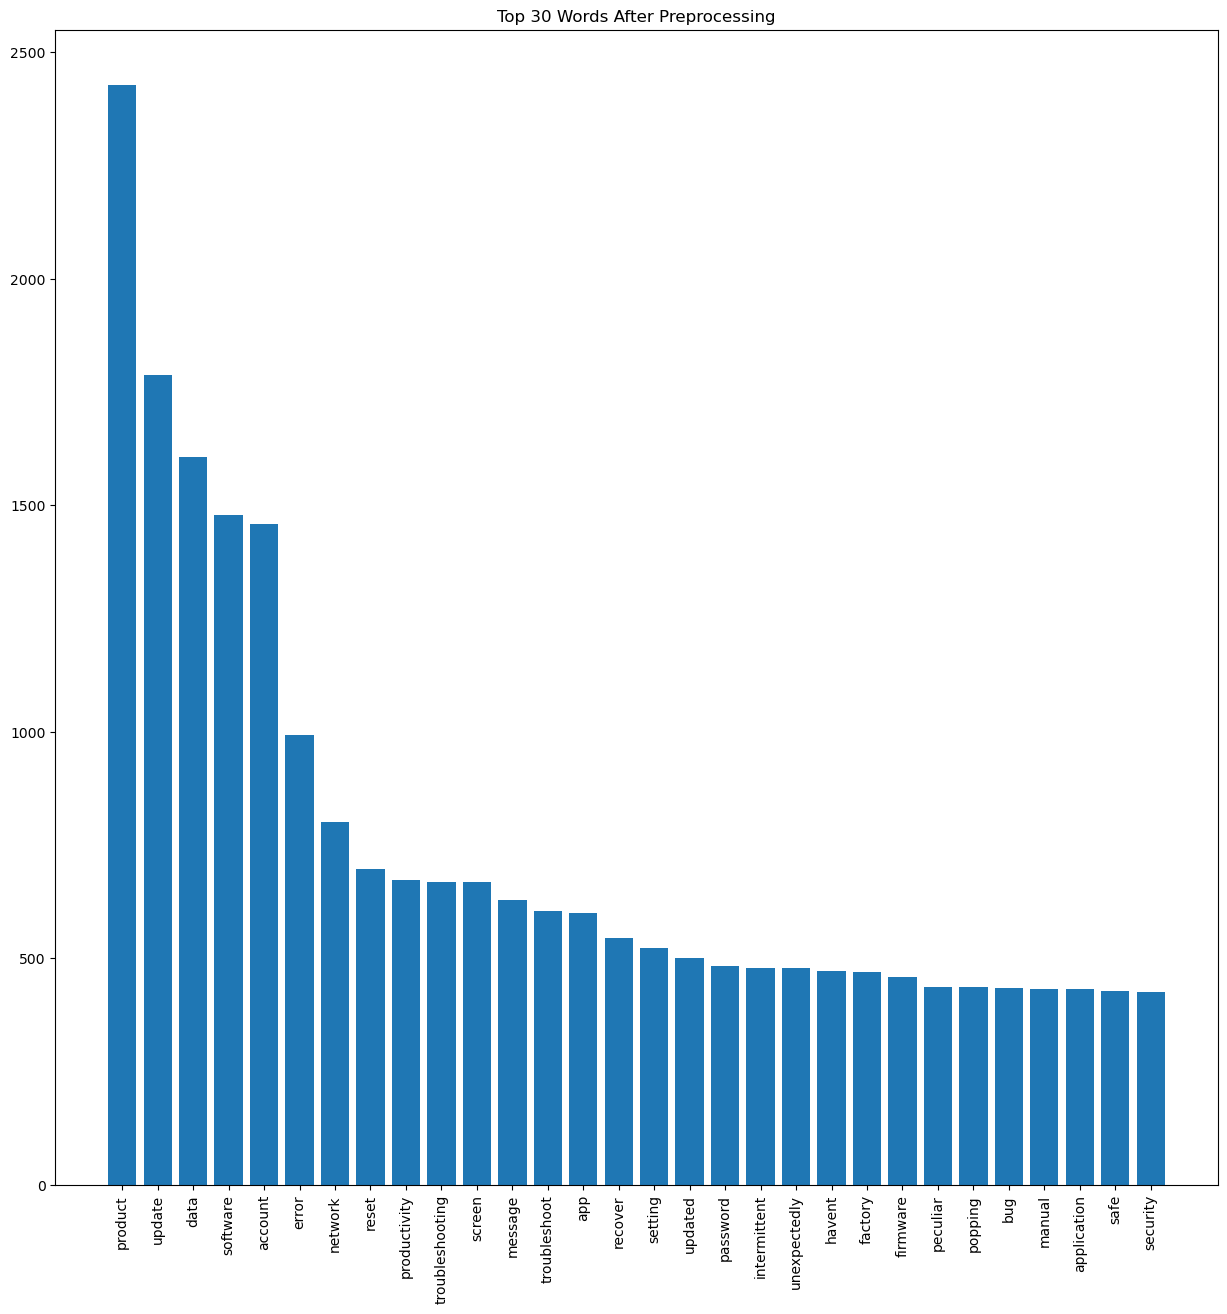

In [13]:
text_data = data_df['processed_text'].astype(str)

all_words = " ".join(text_data).lower().split()
common_words = Counter(all_words).most_common(30)

words, counts = zip(*common_words)

plt.figure(figsize=(15, 15))
plt.bar(words, counts)
plt.xticks(rotation=90)
plt.title("Top 30 Words After Preprocessing")
plt.show()

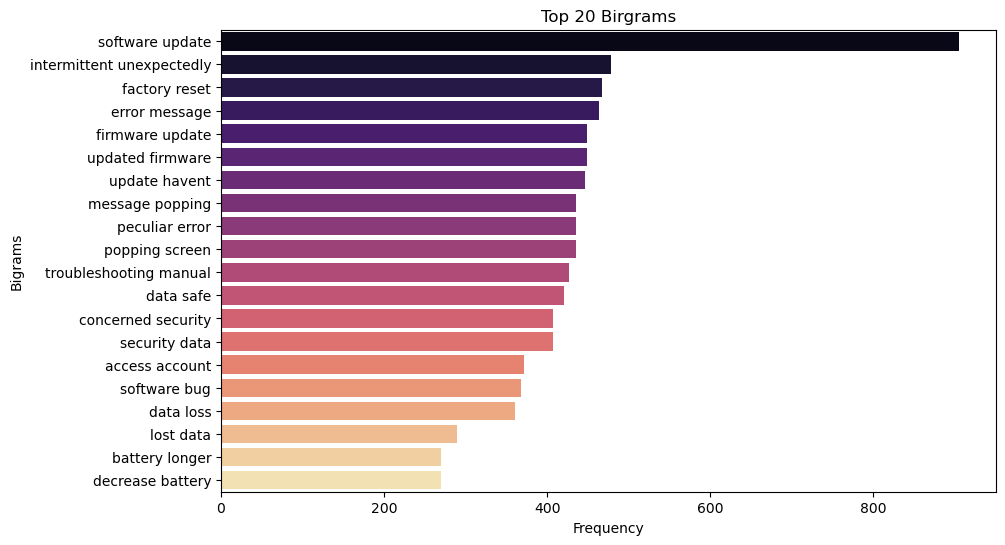

In [14]:
vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english')
x = vectorizer.fit_transform(data_df['processed_text'])
word_counts = x.sum(axis=0).A1
words = vectorizer.get_feature_names_out()
word_freq = list(zip(words, word_counts))
word_freq = sorted(word_freq, key=lambda x: x[1], reverse=True)[:20]
words, counts = zip(*word_freq)

plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='magma')
plt.title("Top 20 Birgrams")
plt.xlabel("Frequency")
plt.ylabel("Bigrams")
plt.show()

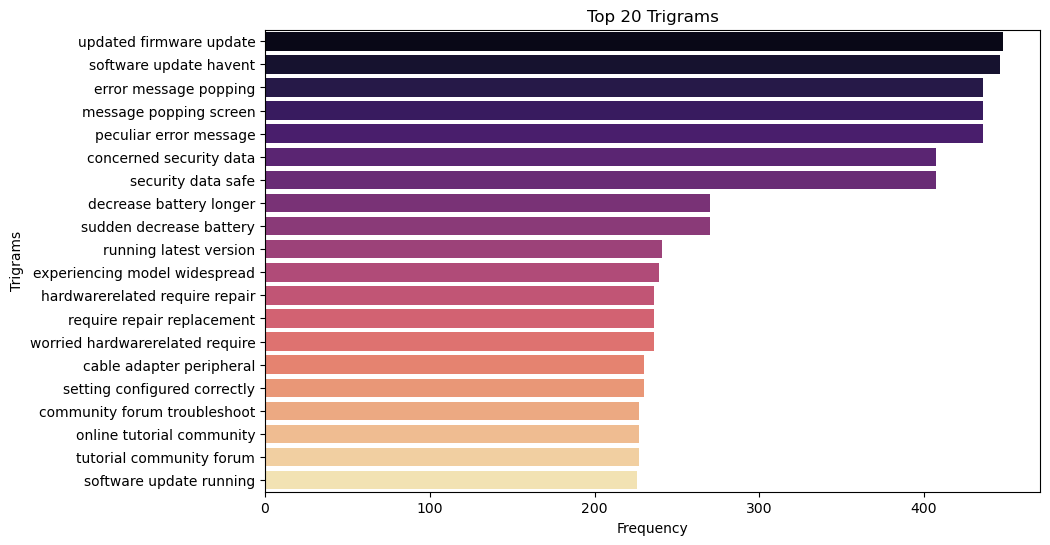

In [15]:
# Change ngram_range to (3,3) for trigrams
vectorizer = CountVectorizer(ngram_range=(3,3), stop_words='english')
x = vectorizer.fit_transform(data_df['processed_text'])

word_counts = x.sum(axis=0).A1
words = vectorizer.get_feature_names_out()
word_freq = list(zip(words, word_counts))
word_freq = sorted(word_freq, key=lambda x: x[1], reverse=True)[:20]
words, counts = zip(*word_freq)

plt.figure(figsize=(10,6))
# Using palette and legend=False to avoid warnings in newer seaborn versions
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='magma', legend=False)
plt.title("Top 20 Trigrams")
plt.xlabel("Frequency")
plt.ylabel("Trigrams")
plt.show()

### TFIDF

In [16]:
tfidf = TfidfVectorizer(max_features=1000,ngram_range=(1,2),min_df=5,max_df=0.7)

X = tfidf.fit_transform(data_df['processed_text'])

In [17]:
X.shape

(8077, 1000)

In [18]:
x_df = pd.DataFrame(X.toarray())
print(x_df.head())

   0    1    2    3    4    5    6    7    8    9    ...  990  991       992  \
0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.000000   
1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.000000   
2  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.362908   
3  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.000000   
4  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.000000   

        993  994  995       996  997  998  999  
0  0.000000  0.0  0.0  0.000000  0.0  0.0  0.0  
1  0.000000  0.0  0.0  0.000000  0.0  0.0  0.0  
2  0.364161  0.0  0.0  0.000000  0.0  0.0  0.0  
3  0.000000  0.0  0.0  0.388146  0.0  0.0  0.0  
4  0.000000  0.0  0.0  0.000000  0.0  0.0  0.0  

[5 rows x 1000 columns]


## LDA Model

LDA + TFIDF

k=2 Perplexity: 631.56, Coherence: 0.2880
k=3 Perplexity: 665.69, Coherence: 0.2533
k=4 Perplexity: 699.30, Coherence: 0.3100
k=5 Perplexity: 704.34, Coherence: 0.4411
k=6 Perplexity: 731.40, Coherence: 0.4255
k=7 Perplexity: 744.01, Coherence: 0.4065
k=8 Perplexity: 776.07, Coherence: 0.4010
k=9 Perplexity: 772.55, Coherence: 0.5266
k=10 Perplexity: 793.45, Coherence: 0.5038
k=11 Perplexity: 803.55, Coherence: 0.5029
k=12 Perplexity: 823.16, Coherence: 0.5326
k=13 Perplexity: 806.88, Coherence: 0.5755
k=14 Perplexity: 837.26, Coherence: 0.6719
k=15 Perplexity: 835.72, Coherence: 0.6493
k=16 Perplexity: 889.89, Coherence: 0.6186
k=17 Perplexity: 871.78, Coherence: 0.6431
k=18 Perplexity: 914.40, Coherence: 0.5505
k=19 Perplexity: 950.25, Coherence: 0.5393
k=20 Perplexity: 904.21, Coherence: 0.6337


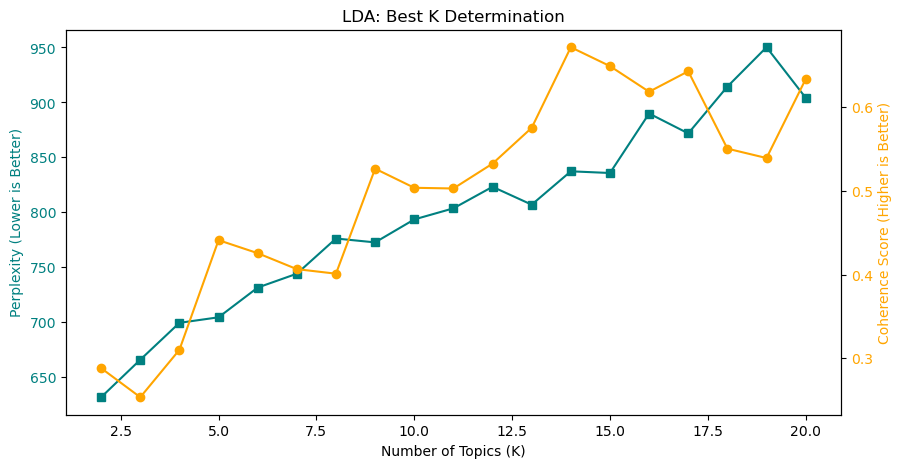

In [19]:
feature_names = tfidf.get_feature_names_out()
tokenized_docs = [doc.split() for doc in data_df['processed_text']]
gensim_dict = Dictionary(tokenized_docs)

topic_counts = list(range(2, 21))
perplexity_scores = []
coherence_scores = []

for k in topic_counts:

    lda = LatentDirichletAllocation(n_components=k, random_state=42, n_jobs=-1, learning_method='batch')
    lda.fit(X)
 
    perplexity_scores.append(lda.perplexity(X))

    topics = []
    for topic_idx, topic in enumerate(lda.components_):
        top_words_idx = topic.argsort()[:-11:-1]
        topics.append([feature_names[i] for i in top_words_idx])
    
    # Calculate Coherence
    cv_model = CoherenceModel(topics=topics, texts=tokenized_docs, dictionary=gensim_dict, coherence='c_v')
    coherence_scores.append(cv_model.get_coherence())
    
    print(f"k={k} Perplexity: {perplexity_scores[-1]:.2f}, Coherence: {coherence_scores[-1]:.4f}")

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(topic_counts, perplexity_scores, marker='s', color='teal', label='Perplexity')
ax1.set_xlabel("Number of Topics (K)")
ax1.set_ylabel("Perplexity (Lower is Better)", color='teal')
ax1.tick_params(axis='y', labelcolor='teal')

ax2 = ax1.twinx()
ax2.plot(topic_counts, coherence_scores, marker='o', color='orange', label='Coherence')
ax2.set_ylabel("Coherence Score (Higher is Better)", color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title("LDA: Best K Determination")
plt.show()

In [20]:
CPU_WATTS = 25
start_time = time.time()

lda = LatentDirichletAllocation(n_components=14,random_state=42,learning_method='batch')

lda.fit(X)
end_time = time.time()

duration = end_time - start_time

energy_kwh = (CPU_WATTS * duration) / 3600000

print(f"Execution Time: {duration:.2f} seconds")
print(f"Estimated Energy: {energy_kwh:.8f} kWh")

Execution Time: 4.31 seconds
Estimated Energy: 0.00002991 kWh


In [21]:
def display_topics(model, feature_names, n_top_words=10):
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        topics.append((topic_idx, top_words))
    return topics

feature_names = tfidf.get_feature_names_out()
topics = display_topics(lda, feature_names)

for idx, words in topics:
    print(f"Topic {idx}: {words}")

Topic 0: ['deleted', 'experiencing', 'model', 'experiencing model', 'widespread', 'model widespread', 'respond', 'yesterday', 'turning', 'turning yesterday']
Topic 1: ['account', 'internet', 'locked', 'connection', 'stable', 'internet connection', 'unlock', 'troubleshoot network', 'establish', 'stable internet']
Topic 2: ['safe', 'data safe', 'concerned', 'security', 'concerned security', 'security data', 'data', 'product', 'refund', 'purchase']
Topic 3: ['productivity', 'lost', 'lost data', 'hindering productivity', 'hindering', 'online', 'forum', 'rely hindering', 'rely', 'community']
Topic 4: ['updated', 'firmware', 'updated firmware', 'firmware update', 'longer', 'update', 'battery', 'decrease', 'decrease battery', 'sudden decrease']
Topic 5: ['charging', 'connecting', 'charger', 'charger charging', 'network', 'trouble', 'home', 'wifi', 'detect', 'wifi network']
Topic 6: ['access', 'access account', 'account', 'correct', 'login', 'invalid', 'credential', 'error correct', 'regain', 

We tested out for the k value of 14 as it has a higher amount of coherence value and lower perplexity value. we also tried the clusters for 15 and 16 but there were more insights present in the K value of 14

| Topic | Professional Label                       |
|------:|------------------------------------------|
| 0     | Model issues                             |
| 1     | Network Stability and connectivity issues|
| 2     | Data Security and refund                 |
| 3     | Critical Workflow Disruption/Production issues|
| 4     | Firmware-Induced Battery Drain           |
| 5     | Home Ecosystem/Charging Setup            |
| 6     | Authentication & Credential Recovery     |
| 7     | Mechanical/Auditory Diagnostics          |
| 8     | UI/UX Visual Glitches                    |
| 9     | Hardware Integrity & Repairs             |
| 10    | Intermittent Feature Flaws               |
| 11    | App Maintenance & Optimization           |
| 12    | Version Parity & Deployment              |
| 13    | Account-Recovery Last Resorts            |


Cluster      | Weight (Count)  | Percentage
---------------------------------------------
Cluster 0    | 484.94         | 6.00%
Cluster 1    | 381.57         | 4.72%
Cluster 2    | 571.61         | 7.08%
Cluster 3    | 512.25         | 6.34%
Cluster 4    | 647.99         | 8.02%
Cluster 5    | 401.67         | 4.97%
Cluster 6    | 325.77         | 4.03%
Cluster 7    | 561.98         | 6.96%
Cluster 8    | 782.99         | 9.69%
Cluster 9    | 419.34         | 5.19%
Cluster 10   | 739.91         | 9.16%
Cluster 11   | 535.87         | 6.63%
Cluster 12   | 871.03         | 10.78%
Cluster 13   | 840.08         | 10.40%


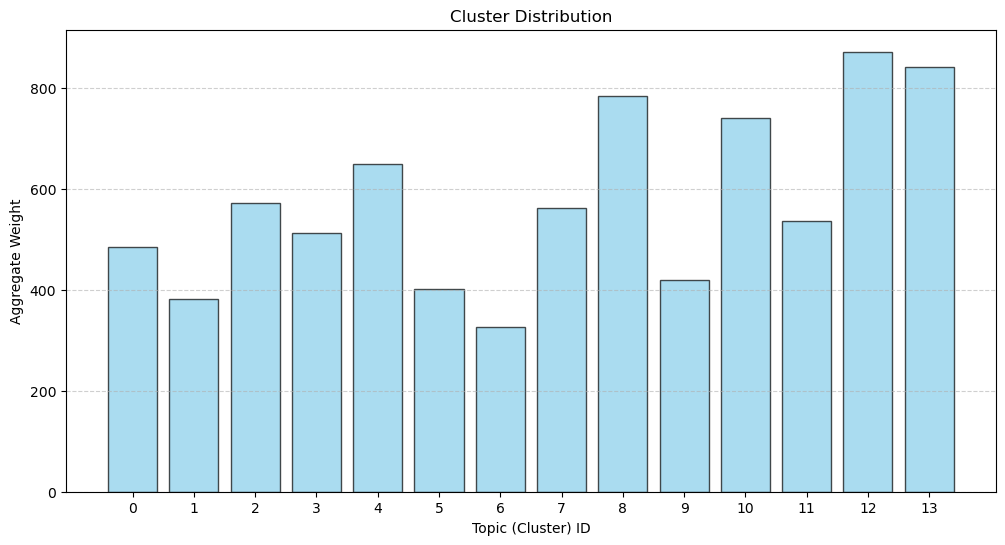

In [22]:
doc_topic_matrix = lda.transform(X)
topic_weights = doc_topic_matrix.sum(axis=0)
total_weight = np.sum(topic_weights)
print(f"\n{'Cluster':<12} | {'Weight (Count)':<15} | {'Percentage'}")
print("-" * 45)

for i, count in enumerate(topic_weights):
    percentage = (count / total_weight) * 100
    print(f"Cluster {i:<4} | {count:<14.2f} | {percentage:.2f}%")
plt.figure(figsize=(12, 6))
plt.bar(range(len(topic_weights)), topic_weights, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Topic (Cluster) ID')
plt.ylabel('Aggregate Weight')
plt.title(f'Cluster Distribution')
plt.xticks(range(len(topic_weights)))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

LDA with Count vectorizer

In [23]:
vectorizer = CountVectorizer(stop_words=list(custom_words), max_df=0.7, min_df=5, max_features=1000, ngram_range=(1, 2) )

X_counts = vectorizer.fit_transform(data_df['processed_text'])


k=2 Perplexity: 363.41, Coherence: 0.3502
k=3 Perplexity: 320.02, Coherence: 0.2999
k=4 Perplexity: 292.97, Coherence: 0.3017
k=5 Perplexity: 257.47, Coherence: 0.4572
k=6 Perplexity: 240.62, Coherence: 0.4410
k=7 Perplexity: 229.32, Coherence: 0.4835
k=8 Perplexity: 222.71, Coherence: 0.5104
k=9 Perplexity: 208.35, Coherence: 0.5505
k=10 Perplexity: 200.36, Coherence: 0.5603
k=11 Perplexity: 190.19, Coherence: 0.5485
k=12 Perplexity: 182.30, Coherence: 0.5933
k=13 Perplexity: 170.88, Coherence: 0.5605
k=14 Perplexity: 167.38, Coherence: 0.6545
k=15 Perplexity: 163.60, Coherence: 0.6687
k=16 Perplexity: 162.34, Coherence: 0.6558
k=17 Perplexity: 153.99, Coherence: 0.6182
k=18 Perplexity: 153.60, Coherence: 0.6209
k=19 Perplexity: 147.70, Coherence: 0.6207
k=20 Perplexity: 144.82, Coherence: 0.6679


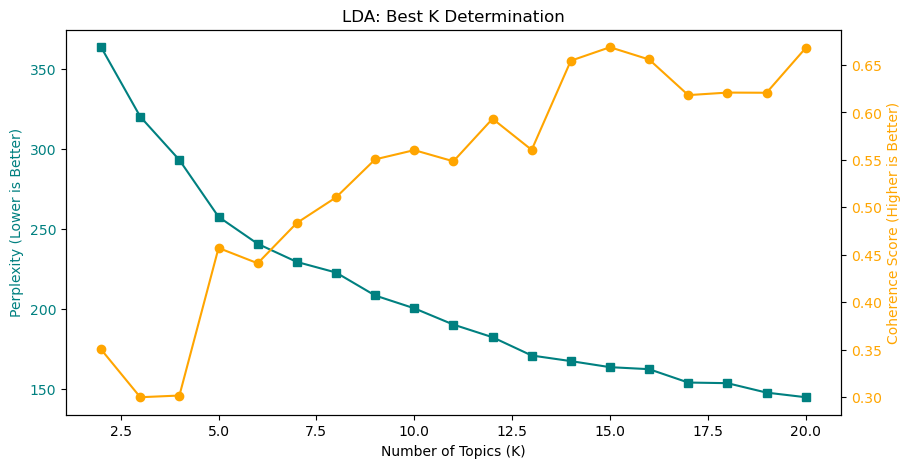

In [24]:
topic_counts = list(range(2, 21))
perplexity_scores = []
coherence_scores = []

feature_names = vectorizer.get_feature_names_out()

for k in topic_counts:
    lda = LatentDirichletAllocation(n_components=k, random_state=42, n_jobs=-1, learning_method='batch')
    lda.fit(X_counts)
    perplexity_scores.append(lda.perplexity(X_counts))
    topics = []
    for topic_idx, topic in enumerate(lda.components_):
        top_words_idx = topic.argsort()[:-11:-1]
        topics.append([feature_names[i] for i in top_words_idx])
    
    cv_model = CoherenceModel(topics=topics, texts=tokenized_docs, dictionary=gensim_dict, coherence='c_v')
    coherence_scores.append(cv_model.get_coherence())
    
    print(f"k={k} Perplexity: {perplexity_scores[-1]:.2f}, Coherence: {coherence_scores[-1]:.4f}")

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(topic_counts, perplexity_scores, marker='s', color='teal', label='Perplexity')
ax1.set_xlabel("Number of Topics (K)")
ax1.set_ylabel("Perplexity (Lower is Better)", color='teal')
ax1.tick_params(axis='y', labelcolor='teal')

ax2 = ax1.twinx()
ax2.plot(topic_counts, coherence_scores, marker='o', color='orange', label='Coherence')
ax2.set_ylabel("Coherence Score (Higher is Better)", color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title("LDA: Best K Determination")
plt.show()

In [25]:
ldavec = LatentDirichletAllocation(n_components=20, random_state=42, learning_method='batch', max_iter=25)

ldavec.fit(X_counts)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",20
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",25
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [26]:
feature_names = vectorizer.get_feature_names_out()
topics = display_topics(ldavec, feature_names)
for idx, words in topics:
    print(f"Topic {idx}: {', '.join(words)}")

Topic 0: data, deleted, recover, lost, lost data, experiencing, model, model widespread, experiencing model, widespread
Topic 1: account, locked, unlock, account account, logging, account locked, logging account, locked unlock, log, unlock account
Topic 2: data, safe, data safe, security, concerned, concerned security, security data, product, product concerned, mobile
Topic 3: update, software, software update, havent, update havent, send, product, ill, little, friend
Topic 4: updated, update, firmware, updated firmware, firmware update, manual, troubleshooting, troubleshooting manual, productivity, hindering productivity
Topic 5: network, connecting, trouble, home, wifi, wifi network, detect, connecting home, detect network, home wifi
Topic 6: longer, battery, decrease, decrease battery, sudden, sudden decrease, battery longer, feel, money, free
Topic 7: website, configuration, setting configuration, setting, troubleshooting, troubleshooting website, hardware, strange, noise, strange 

We tried LDA with k value of 15 and that of 20 as they have the highest coherence value and comparitively less perplexity value. That is k=15 Perplexity: 163.60, Coherence: 0.6687 and k=20 Perplexity: 144.82, Coherence: 0.6679 Because that is the one dip in the Perplexity values which we see around. K value of 20 has performed better compared to that of other as there is less noise and less overlaping.

| Topic | Labels                                     |
|------:|--------------------------------------------|
| 0     | Widespread Model Data Loss                 |
| 1     | System-Level Account Lockouts              |
| 2     | Mobile Data Privacy Concerns               |
| 3     | Social/Peer Update Inquiries               |
| 4     | Firmware-Driven Productivity Loss          |
| 5     | Home WiFi Setup & Detection                |
| 6     | Sudden Battery Degradation                 |
| 7     | Mechanical/Hardware Noise                  |
| 8     | UI/UX Visual Anomalies                     |
| 9     | ISP Stability & Connection Integrity       |
| 10    | Intermittent Feature Regressions           |
| 11    | Application Hygiene/Cache Issues           |
| 12    | Version Parity & Build Management          |
| 13    | Product Factory Resets                     |
| 14    | Peripherals & Community Support            |
| 15    | Critical Application Crashes               |
| 16    | Gaming/Interactive Configuration           |
| 17    | Hardware Repair/Warranty Claims            |
| 18    | Document Retrieval & File Loss             |
| 19    | Self-Service Credential Recovery           |

Cluster      | Weight (Count)  | Percentage
Cluster 0    | 496.56         | 6.15%
Cluster 1    | 197.01         | 2.44%
Cluster 2    | 325.15         | 4.03%
Cluster 3    | 492.41         | 6.10%
Cluster 4    | 785.29         | 9.72%
Cluster 5    | 195.29         | 2.42%
Cluster 6    | 268.62         | 3.33%
Cluster 7    | 462.17         | 5.72%
Cluster 8    | 380.05         | 4.71%
Cluster 9    | 192.40         | 2.38%
Cluster 10   | 505.89         | 6.26%
Cluster 11   | 326.80         | 4.05%
Cluster 12   | 462.30         | 5.72%
Cluster 13   | 1208.62        | 14.96%
Cluster 14   | 534.69         | 6.62%
Cluster 15   | 222.83         | 2.76%
Cluster 16   | 216.47         | 2.68%
Cluster 17   | 273.55         | 3.39%
Cluster 18   | 183.25         | 2.27%
Cluster 19   | 347.65         | 4.30%


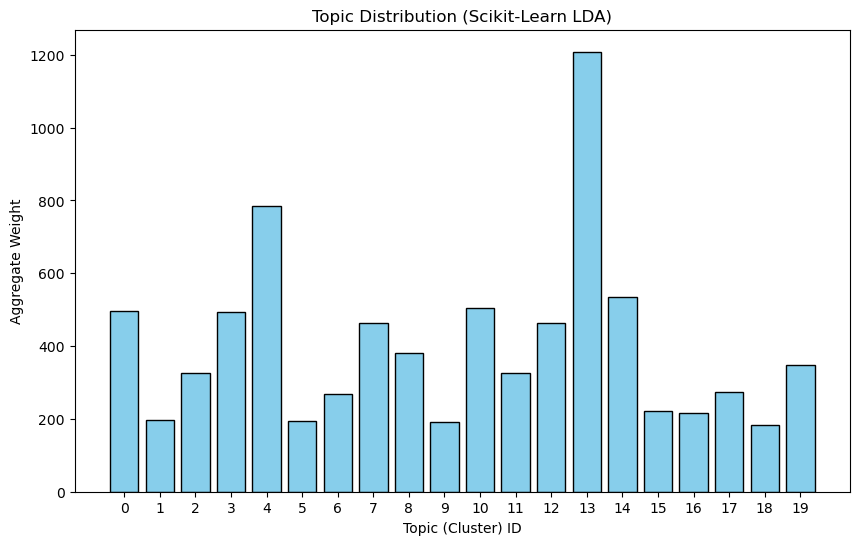

In [27]:
doc_topic_matrix = ldavec.transform(X_counts)
topic_counts = doc_topic_matrix.sum(axis=0)
total_weight = np.sum(topic_counts)

print(f"{'Cluster':<12} | {'Weight (Count)':<15} | {'Percentage'}")

for i, count in enumerate(topic_counts):
    percentage = (count / total_weight) * 100
    print(f"Cluster {i:<4} | {count:<14.2f} | {percentage:.2f}%")
plt.figure(figsize=(10, 6))
plt.bar(range(len(topic_counts)), topic_counts, color='skyblue', edgecolor='black')
plt.xlabel('Topic (Cluster) ID')
plt.ylabel('Aggregate Weight')
plt.title('Topic Distribution (Scikit-Learn LDA)')
plt.xticks(range(len(topic_counts)))
plt.show()

LDA with Gensim

In [28]:
import gensim
from gensim import corpora
tokenized_data = [text.split() for text in data_df['processed_text']]
diction = corpora.Dictionary(tokenized_data)
diction.filter_extremes(no_below=5, no_above=0.7)

corpus = [diction.doc2bow(text) for text in tokenized_data]

k=2 Perplexity: 56.18, Log-Perplexity: -5.81, Coherence: 0.2490
k=3 Perplexity: 53.04, Log-Perplexity: -5.73, Coherence: 0.2665
k=4 Perplexity: 53.51, Log-Perplexity: -5.74, Coherence: 0.2193
k=5 Perplexity: 53.10, Log-Perplexity: -5.73, Coherence: 0.2394
k=6 Perplexity: 51.16, Log-Perplexity: -5.68, Coherence: 0.2819
k=7 Perplexity: 50.89, Log-Perplexity: -5.67, Coherence: 0.2698
k=8 Perplexity: 48.81, Log-Perplexity: -5.61, Coherence: 0.2805
k=9 Perplexity: 49.15, Log-Perplexity: -5.62, Coherence: 0.3064
k=10 Perplexity: 47.31, Log-Perplexity: -5.56, Coherence: 0.3006
k=11 Perplexity: 46.20, Log-Perplexity: -5.53, Coherence: 0.3447
k=12 Perplexity: 46.30, Log-Perplexity: -5.53, Coherence: 0.3609
k=13 Perplexity: 48.91, Log-Perplexity: -5.61, Coherence: 0.3306
k=14 Perplexity: 48.25, Log-Perplexity: -5.59, Coherence: 0.3548
k=15 Perplexity: 48.84, Log-Perplexity: -5.61, Coherence: 0.3399
k=16 Perplexity: 49.17, Log-Perplexity: -5.62, Coherence: 0.3565
k=17 Perplexity: 49.12, Log-Perpl

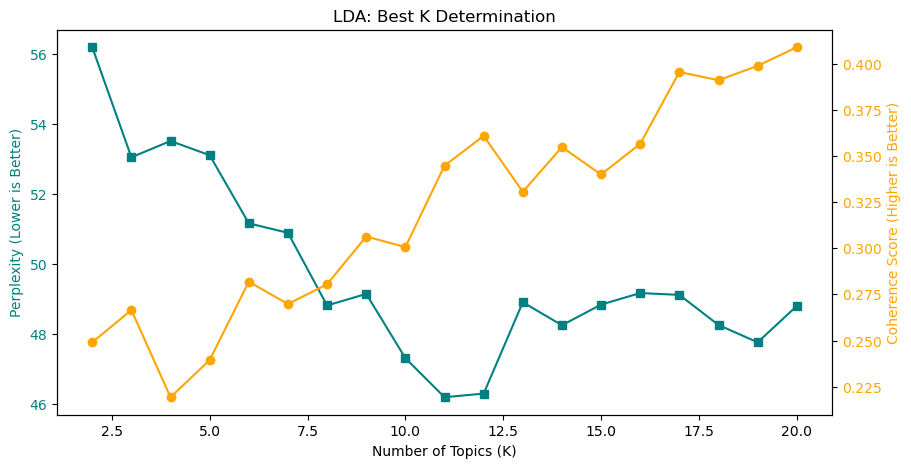

In [29]:
topic_counts = list(range(2, 21))
perplexity_scores = []
log_perplexity_scores = []
coherence_scores = []

for k in topic_counts:
    lda_model = gensim.models.LdaModel(
        corpus=corpus, 
        id2word=diction, 
        num_topics=k, 
        random_state=42, 
        passes=10, 
        alpha='auto'
    )

    log_perp = lda_model.log_perplexity(corpus)
    log_perplexity_scores.append(log_perp)
    normal_perplexity = np.exp2(-log_perp)
    perplexity_scores.append(normal_perplexity)
    
    coherence_model = CoherenceModel(
        model=lda_model, 
        texts=tokenized_docs, 
        dictionary=diction, 
        coherence='c_v'
    )
    coherence_scores.append(coherence_model.get_coherence())
    
    print(f"k={k} Perplexity: {normal_perplexity:.2f}, Log-Perplexity: {log_perp:.2f}, Coherence: {coherence_scores[-1]:.4f}")

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(topic_counts, perplexity_scores, marker='s', color='teal', label='Perplexity')
ax1.set_xlabel("Number of Topics (K)")
ax1.set_ylabel("Perplexity (Lower is Better)", color='teal')
ax1.tick_params(axis='y', labelcolor='teal')

ax2 = ax1.twinx()
ax2.plot(topic_counts, coherence_scores, marker='o', color='orange', label='Coherence')
ax2.set_ylabel("Coherence Score (Higher is Better)", color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title("LDA: Best K Determination")
plt.show()

In [30]:
lda_gensim = gensim.models.LdaModel(
    corpus=corpus,
    id2word=diction,
    num_topics=19, 
    random_state=42,
    update_every=1,
    passes=10,
    alpha='auto',
    per_word_topics=True
)


for i, topic in lda_gensim.show_topics(formatted=True, num_topics=19, num_words=20):
    print(f"Topic {i}: {topic}")

Topic 0: 0.084*"version" + 0.083*"account" + 0.080*"access" + 0.078*"running" + 0.077*"latest" + 0.075*"update" + 0.064*"software" + 0.048*"correct" + 0.042*"login" + 0.039*"invalid" + 0.039*"error" + 0.037*"credential" + 0.037*"regain" + 0.037*"displaying" + 0.025*"window" + 0.015*"start" + 0.012*"command" + 0.011*"following" + 0.010*"updated" + 0.010*"firmware"
Topic 1: 0.130*"file" + 0.106*"data" + 0.104*"loss" + 0.094*"encountered" + 0.080*"retrieve" + 0.077*"document" + 0.075*"disappeared" + 0.027*"project" + 0.023*"main" + 0.021*"external" + 0.020*"unexpectedly" + 0.020*"intermittent" + 0.019*"website" + 0.019*"experience" + 0.011*"example" + 0.008*"refer" + 0.007*"clicking" + 0.007*"marked" + 0.006*"believe" + 0.006*"incorrect"
Topic 2: 0.094*"intermittent" + 0.094*"unexpectedly" + 0.060*"feature" + 0.051*"application" + 0.051*"occurs" + 0.050*"consistently" + 0.047*"product" + 0.046*"sorry" + 0.021*"browser" + 0.018*"case" + 0.018*"report" + 0.018*"think" + 0.017*"bag" + 0.017*

In [31]:
for i, topic in lda_gensim.show_topics(formatted=False, num_topics=19, num_words=20):
    words = [word for word, weight in topic]
    print(f"Topic {i}: {', '.join(words)}")

Topic 0: version, account, access, running, latest, update, software, correct, login, invalid, error, credential, regain, displaying, window, start, command, following, updated, firmware
Topic 1: file, data, loss, encountered, retrieve, document, disappeared, project, main, external, unexpectedly, intermittent, website, experience, example, refer, clicking, marked, believe, incorrect
Topic 2: intermittent, unexpectedly, feature, application, occurs, consistently, product, sorry, browser, case, report, think, bag, install, said, whats, added, copy, valid, advance
Topic 3: update, updated, product, firmware, purchase, received, buy, good, ask, wont, sell, great, refund, money, day, javascript, inventory, sale, sold, cart
Topic 4: message, error, screen, peculiar, popping, remove, got, payment, explain, accept, receive, difference, november, send, box, youve, reading, mobile, broken, country
Topic 5: connecting, network, home, trouble, wifi, detect, difficult, glitch, frequently, software

WE tried for k values of 12,14, 17 and 19. For the K value of 19 the topics are generally more clearer and is giving good distinct clusters. The distribution is also even. K value of 19 dominated among all the others.

| Topic ID |  Label                           |
|---------:|----------------------------------|
| 0        | Software Version & Access        |
| 1        | Document & File Loss             |
| 2        | Intermittent App Bugs            |
| 3        | Firmware & Sales                 |
| 4        | Screen Error Messages            |
| 5        | Local Network Connectivity       |
| 6        | Data Security & Safety           |
| 7        | Peripheral & Battery Health      |
| 8        | Manual Troubleshooting           |
| 9        | Productivity & Procurement       |
| 10       | Account Recovery                 |
| 11       | Hardware Audio Defects           |
| 12       | App Cache Management             |
| 13       | Critical System Crashes          |
| 14       | Internet Stability               |
| 15       | Account Configuration            |
| 16       | Urgent File Recovery             |
| 17       | Display & Power Supply           |
| 18       | Hardware Repair/Warranty         |

Cluster      | Weight (Count)  | Percentage
Cluster 0    | 723.67         | 9.64%
Cluster 1    | 352.52         | 4.69%
Cluster 2    | 1225.71        | 16.32%
Cluster 3    | 1609.96        | 21.44%
Cluster 4    | 684.07         | 9.11%
Cluster 5    | 519.06         | 6.91%
Cluster 6    | 656.66         | 8.74%
Cluster 7    | 994.86         | 13.25%
Cluster 8    | 956.92         | 12.74%
Cluster 9    | 1254.42        | 16.70%
Cluster 10   | 870.59         | 11.59%
Cluster 11   | 522.62         | 6.96%
Cluster 12   | 574.86         | 7.65%
Cluster 13   | 959.98         | 12.78%
Cluster 14   | 691.54         | 9.21%
Cluster 15   | 781.90         | 10.41%
Cluster 16   | 300.22         | 4.00%
Cluster 17   | 603.03         | 8.03%
Cluster 18   | 736.89         | 9.81%


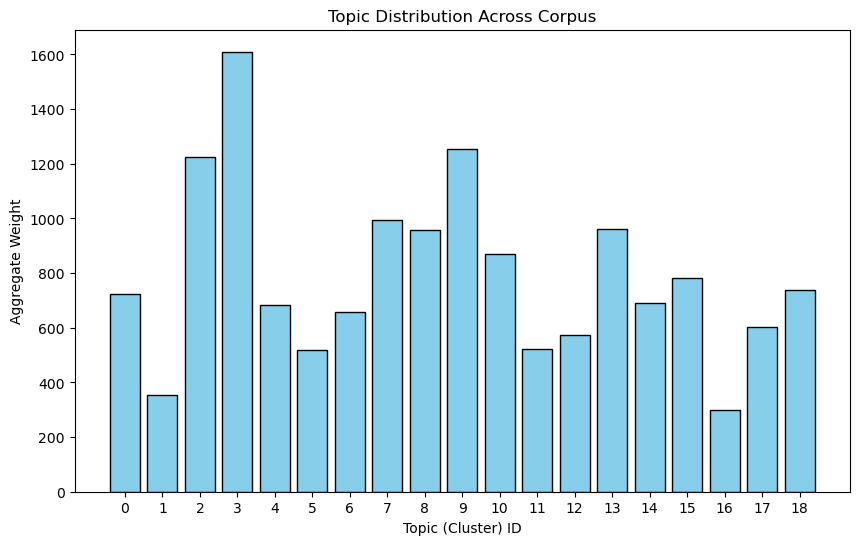

In [32]:
topic_counts = np.zeros(lda_gensim.num_topics)

for doc_bow in corpus:
    doc_topics = lda_gensim.get_document_topics(doc_bow)
    for topic_id, weight in doc_topics:
        topic_counts[topic_id] += weight

total_weight = np.sum(topic_counts)

for doc_bow in corpus:
    doc_topics = lda_gensim.get_document_topics(doc_bow)
    for topic_id, weight in doc_topics:
        topic_counts[topic_id] += weight

print(f"{'Cluster':<12} | {'Weight (Count)':<15} | {'Percentage'}")

for i, count in enumerate(topic_counts):
    percentage = (count / total_weight) * 100
    print(f"Cluster {i:<4} | {count:<14.2f} | {percentage:.2f}%")
plt.figure(figsize=(10, 6))
plt.bar(range(len(topic_counts)), topic_counts, color='skyblue', edgecolor='black')
plt.xlabel('Topic (Cluster) ID')
plt.ylabel('Aggregate Weight')
plt.title('Topic Distribution Across Corpus')
plt.xticks(range(lda_gensim.num_topics))
plt.show()

In [33]:
from gensim.models import CoherenceModel

coherence_model = CoherenceModel(
    model=lda_gensim, 
    texts=tokenized_data, 
    dictionary=diction, 
    coherence='c_v'
)
coherence_score = coherence_model.get_coherence()
print(f"Coherence Score: {coherence_score:.4f}")

Coherence Score: 0.3988


In [34]:
def get_dominant_topic(model, corpus):
    topic_results = []
    for i, row in enumerate(model[corpus]):
        row = sorted(row[0] if isinstance(row, tuple) else row, key=lambda x: x[1], reverse=True)
        topic_num, prop_topic = row[0]
        topic_results.append((int(topic_num), round(prop_topic, 4)))
    return topic_results
results = get_dominant_topic(lda_gensim, corpus)
data_df['Cluster_ID'] = [r[0] for r in results]
data_df['Confidence'] = [r[1] for r in results]

Out of all these LDa with Gensim model seems to give more distinct topics but the TFIDF has higher scores interms of coherence